# 03 — MOEA Optimization rehecho



In [2]:

import os
import time
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.base import clone

try:
    from pymoo.algorithms.moo.nsga2 import NSGA2
    from pymoo.algorithms.moo.nsga3 import NSGA3
    from pymoo.algorithms.moo.spea2 import SPEA2
    from pymoo.optimize import minimize
    from pymoo.core.problem import Problem
    from pymoo.core.callback import Callback
    from pymoo.util.ref_dirs import get_reference_directions
    from pymoo.operators.sampling.rnd import FloatRandomSampling
    from pymoo.operators.crossover.sbx import SBX
    from pymoo.operators.mutation.pm import PM
    from pymoo.termination import get_termination
    from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting
    from pymoo.indicators.igd import IGD
    from pymoo.indicators.hv import HV
except ImportError as exc:
    raise ImportError(
        "Este notebook requiere `pymoo`. Instálalo con: pip install pymoo"
    ) from exc

RANDOM_SEED = 42
generador_aleatorio = np.random.default_rng(RANDOM_SEED)

# ---------------------------------------------------------
# Rutas base (ajusta DIR_PROYECTO si trabajas con rutas absolutas)
# ---------------------------------------------------------
DIR_PROYECTO = "."
DIR_BASE = os.path.join(DIR_PROYECTO, "Datos", "Transformados", 'Optimizacion')
DIR_EDA = os.path.join(DIR_BASE, 'eda')

DIR_MODELOS_SURROGATE = os.path.join(DIR_BASE, "models", "surrogates")
OUT_DIR = os.path.join(DIR_BASE, "outputs", "moea")
FIG_DIR = os.path.join(OUT_DIR, "figures")

os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

DATA_PATH = os.path.join(DIR_EDA, "dataset_clean.csv")
ARTIFACT_PATH = os.path.join(DIR_MODELOS_SURROGATE, "models.pkl")
INFO_PATH = os.path.join(DIR_MODELOS_SURROGATE, "best_models_info.json")

assert os.path.exists(DATA_PATH), f"No existe Opt_dataset_4Objectives_CC.csv en: {DATA_PATH}"
assert os.path.exists(ARTIFACT_PATH), f"No existe models.pkl en: {ARTIFACT_PATH}"
print("DATA_PATH:", DATA_PATH)
print("ARTIFACT_PATH:", ARTIFACT_PATH)


DATA_PATH: .\Datos\Transformados\Optimizacion\eda\dataset_clean.csv
ARTIFACT_PATH: .\Datos\Transformados\Optimizacion\models\surrogates\models.pkl


## 1) Cargar dataset + artefacto del notebook 02

In [3]:
df = pd.read_csv(DATA_PATH)
artifact = joblib.load(ARTIFACT_PATH)

assert isinstance(artifact, dict), "models.pkl debe contener un diccionario"
for key in ["models", "bounds", "X_cols", "Y_cols", "random_seed"]:
    assert key in artifact, f"Falta clave en artifact: {key}"

modelos_base_ganadores = artifact["models"]
bounds = artifact["bounds"]
X_cols = artifact["X_cols"]
Y_cols = artifact["Y_cols"]

faltantes = [c for c in X_cols + Y_cols if c not in df.columns]
assert not faltantes, f"Faltan columnas en el dataset limpio: {faltantes}"

# ⚠️ SOLO seleccionar columnas, NO limpiar otra vez
df_xy = df[X_cols + Y_cols].copy()

# Diagnóstico simple
print("Shape dataset cargado:", df_xy.shape)
print("Duplicados presentes:", df_xy.duplicated().sum())

# Construcción de X e Y
X_data = df_xy[X_cols].values
Y_data = df_xy[Y_cols].values

# Bounds
xl = np.array([bounds[c][0] for c in X_cols], dtype=float)
xu = np.array([bounds[c][1] for c in X_cols], dtype=float)

print("X_cols:", X_cols)
print("Y_cols:", Y_cols)
print("Targets en models.pkl:", list(modelos_base_ganadores.keys()))

display(df_xy.head())

Shape dataset cargado: (1700, 10)
Duplicados presentes: 395
X_cols: ['hm', 'alpha_m', 'er', 'dsi', 'bst', 'bss']
Y_cols: ['TC', 'TcogPP', 'ned', 'TriPP']
Targets en models.pkl: ['TC', 'TcogPP', 'ned', 'TriPP']


,hm,alpha_m,er,dsi,bst,bss,TC,TcogPP,ned,TriPP
0,3.2,0.95,1.2,2.4,46.5,5.1,7.543477,0.000590,-0.809682,0.002764
1,1.2,0.95,1.0,0.1,45.0,4.8,5.377060,0.206311,-0.918555,0.225746
2,1.2,0.75,1.3,0.4,48.0,4.8,5.048992,0.033728,-0.908788,0.060608
3,1.4,0.85,0.8,0.1,49.0,4.7,5.681045,0.238174,-0.917285,0.244254
4,1.2,0.90,2.0,0.1,45.0,4.8,5.177121,0.016478,-0.914834,0.054130


## 2) Reconstruir el mismo split del notebook 02



In [4]:

X_train_full, X_test, Y_train_full, Y_test = train_test_split(
    X_data, Y_data, test_size=0.2, random_state=RANDOM_SEED
)

print("Train full:", X_train_full.shape, Y_train_full.shape)
print("Test fijo  :", X_test.shape, Y_test.shape)

n_total = len(df_xy)
n_train_full = len(X_train_full)
n_test = len(X_test)

print(f"Total observaciones disponibles: {n_total}")
print(f"Observaciones en train completo: {n_train_full}")
print(f"Observaciones en test fijo: {n_test}")


Train full: (1360, 6) (1360, 4)
Test fijo  : (340, 6) (340, 4)
Total observaciones disponibles: 1700
Observaciones en train completo: 1360
Observaciones en test fijo: 340


## 3) Eficiencia del dato y punto de parada
En este bloque se busca cumplir el **objetivo 2** del reto: usar el **menor número posible de observaciones**.

Aquí **una observación equivale a una pasada por el dataset** para entrenar el surrogate con un subconjunto de datos.
En el contexto real, cada pasada completa puede tardar **~45 minutos**, así que no interesa seguir aumentando observaciones si la mejora ya es marginal.

La idea es analizar:
- cómo evolucionan `R²_global` y `RMSE_global` al aumentar el porcentaje de observaciones,
- cuál es la **ganancia marginal** entre porcentajes consecutivos,
- y a partir de qué punto **ya no merece la pena seguir añadiendo observaciones**.


In [5]:
# Porcentajes de observaciones a probar
porcentajes = [0.10, 0.15, 0.20, 0.25, 0.33, 0.40, 0.50, 0.60, 0.75, 0.90, 1.00]
seeds_obs = [1, 7, 21, 42, 99]

# Umbrales para detectar el punto a partir del cual ya no compensa seguir añadiendo observaciones
R2_MIN_FRAC_OF_BEST = 0.98     
DELTA_R2_STOP = 0.005          
DELTA_RMSE_STOP = 0.01          
MIN_CONSECUTIVE_STABLE = 2      
REAL_FULL_PASS_MINUTES = 45     

def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def entrenar_modelos_por_objetivo(X_sub, Y_sub, modelos_prototipo, Y_cols):
    modelos_entrenados = {}
    for j, target in enumerate(Y_cols):
        modelo = clone(modelos_prototipo[target])
        modelo.fit(X_sub, Y_sub[:, j])
        modelos_entrenados[target] = modelo
    return modelos_entrenados

def predecir_multioutput(modelos_entrenados, X):
    F = np.zeros((len(X), len(Y_cols)), dtype=float)
    for j, target in enumerate(Y_cols):
        F[:, j] = modelos_entrenados[target].predict(X)
    return F

resultados_detallados = []

for pct in porcentajes:
    for seed in seeds_obs:
        if pct < 1.0:
            X_sub, _, Y_sub, _ = train_test_split(
                X_train_full,
                Y_train_full,
                train_size=pct,
                random_state=seed
            )
        else:
            X_sub, Y_sub = X_train_full, Y_train_full

        modelos_temp = entrenar_modelos_por_objetivo(X_sub, Y_sub, modelos_base_ganadores, Y_cols)
        Y_pred = predecir_multioutput(modelos_temp, X_test)

        fila = {
            "pct_train": pct,
            "n_obs_train": len(X_sub),
            "seed": seed,
            "R2_global": float(1 - np.sum((Y_test - Y_pred) ** 2) / np.sum((Y_test - Y_test.mean(axis=0)) ** 2)),
            "RMSE_global": rmse(Y_test, Y_pred),
            "tiempo_equiv_full_pass_min": pct * REAL_FULL_PASS_MINUTES,
        }

        for j, target in enumerate(Y_cols):
            y_t = Y_test[:, j]
            y_p = Y_pred[:, j]
            ss_res = np.sum((y_t - y_p) ** 2)
            ss_tot = np.sum((y_t - y_t.mean()) ** 2)
            fila[f"R2_{target}"] = float(1 - ss_res / ss_tot) if ss_tot > 0 else np.nan
            fila[f"RMSE_{target}"] = rmse(y_t, y_p)

        resultados_detallados.append(fila)

obs_detail_df = pd.DataFrame(resultados_detallados).sort_values(["pct_train", "seed"]).reset_index(drop=True)
display(obs_detail_df.head())

obs_detail_path = os.path.join(OUT_DIR, "obs_efficiency_detail.csv")
obs_detail_df.to_csv(obs_detail_path, index=False)
print("Saved:", obs_detail_path)


,pct_train,n_obs_train,seed,R2_global,RMSE_global,tiempo_equiv_full_pass_min,R2_TC,RMSE_TC,R2_TcogPP,RMSE_TcogPP,R2_ned,RMSE_ned,R2_TriPP,RMSE_TriPP
0,0.1,136,1,0.988723,0.071211,4.5,0.990229,0.131940,0.813008,0.036243,0.851612,0.018873,0.843915,0.034732
1,0.1,136,7,0.968004,0.119952,4.5,0.969475,0.233203,0.772139,0.040008,0.914547,0.014322,0.823384,0.036946
2,0.1,136,21,0.987907,0.073744,4.5,0.989873,0.134325,0.743724,0.042430,0.919975,0.013860,0.777830,0.041437
3,0.1,136,42,0.988746,0.071141,4.5,0.990418,0.130660,0.791549,0.038266,0.872955,0.017464,0.818500,0.037453
4,0.1,136,99,0.989409,0.069013,4.5,0.991152,0.125551,0.779690,0.039340,0.924992,0.013419,0.798100,0.039502


Saved: .\Datos\Transformados\Optimizacion\outputs\moea\obs_efficiency_detail.csv


In [6]:
agg_dict = {
    "n_obs_train": ["mean"],
    "R2_global": ["mean", "std"],
    "RMSE_global": ["mean", "std"],
    "tiempo_equiv_full_pass_min": ["mean"],
}
for target in Y_cols:
    agg_dict[f"R2_{target}"] = ["mean", "std"]
    agg_dict[f"RMSE_{target}"] = ["mean", "std"]

resumen_porcentajes = obs_detail_df.groupby("pct_train").agg(agg_dict)
resumen_porcentajes.columns = ["_".join(col).strip("_") for col in resumen_porcentajes.columns]
resumen_porcentajes = resumen_porcentajes.reset_index().sort_values("pct_train").reset_index(drop=True)

# Ganancia marginal entre porcentajes consecutivos
resumen_porcentajes["delta_pct"] = resumen_porcentajes["pct_train"].diff()
resumen_porcentajes["delta_obs"] = resumen_porcentajes["n_obs_train_mean"].diff()
resumen_porcentajes["delta_r2"] = resumen_porcentajes["R2_global_mean"].diff()
resumen_porcentajes["delta_rmse"] = -resumen_porcentajes["RMSE_global_mean"].diff()  # positivo = mejora
resumen_porcentajes["delta_rmse_rel"] = resumen_porcentajes["delta_rmse"] / resumen_porcentajes["RMSE_global_mean"].shift(1)





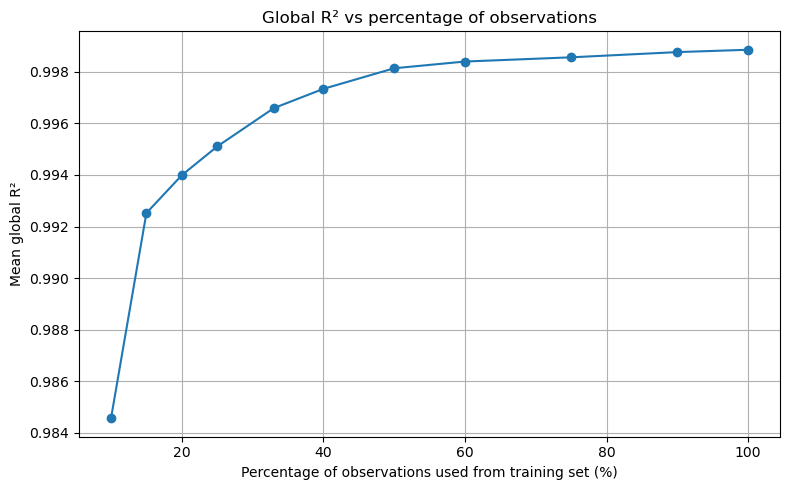

Saved: .\Datos\Transformados\Optimizacion\outputs\moea\figures\obs_efficiency_r2_global.png


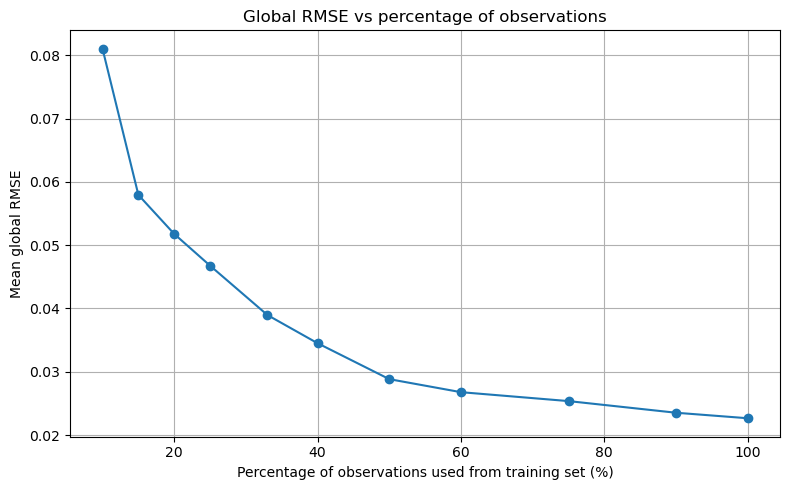

Saved: .\Datos\Transformados\Optimizacion\outputs\moea\figures\obs_efficiency_rmse_global.png


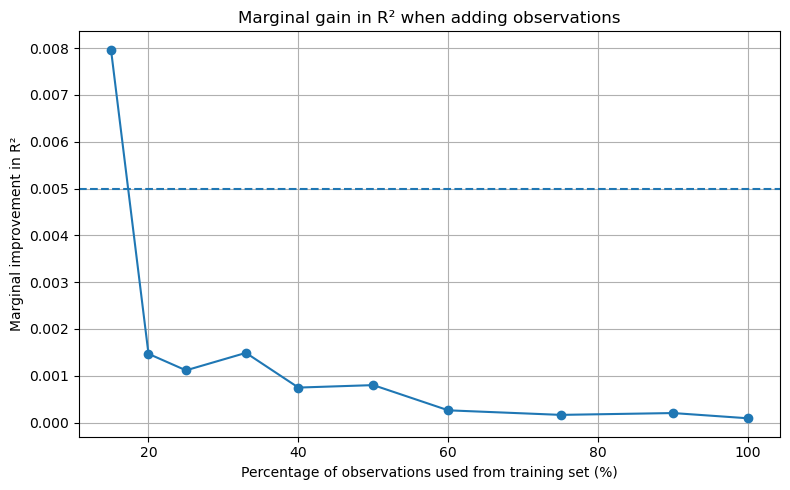

Saved: .\Datos\Transformados\Optimizacion\outputs\moea\figures\obs_efficiency_delta_r2.png


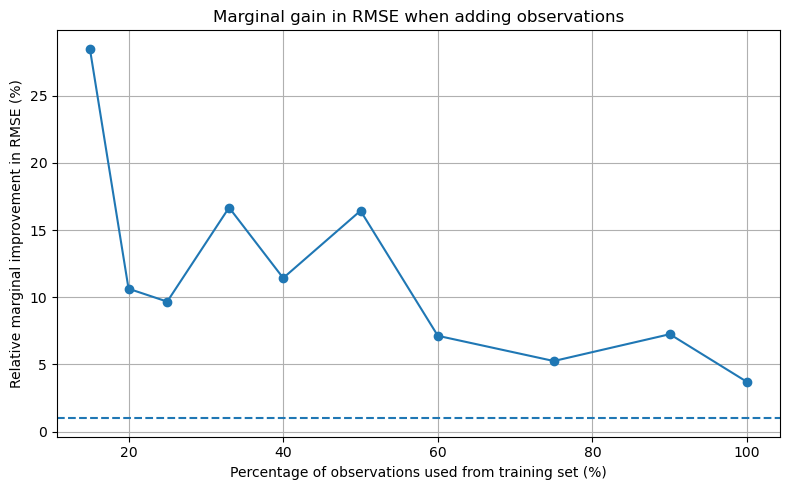

Saved: .\Datos\Transformados\Optimizacion\outputs\moea\figures\obs_efficiency_delta_rmse_rel.png


In [7]:
# Global R2 / RMSE visualization
plt.figure(figsize=(8,5))
plt.plot(resumen_porcentajes["pct_train"] * 100, resumen_porcentajes["R2_global_mean"], marker="o")
plt.xlabel("Percentage of observations used from training set (%)")
plt.ylabel("Mean global R²")
plt.title("Global R² vs percentage of observations")
plt.grid(True)
plt.tight_layout()
ruta_fig = os.path.join(FIG_DIR, "obs_efficiency_r2_global.png")
plt.savefig(ruta_fig, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", ruta_fig)

plt.figure(figsize=(8,5))
plt.plot(resumen_porcentajes["pct_train"] * 100, resumen_porcentajes["RMSE_global_mean"], marker="o")
plt.xlabel("Percentage of observations used from training set (%)")
plt.ylabel("Mean global RMSE")
plt.title("Global RMSE vs percentage of observations")
plt.grid(True)
plt.tight_layout()
ruta_fig = os.path.join(FIG_DIR, "obs_efficiency_rmse_global.png")
plt.savefig(ruta_fig, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", ruta_fig)

# Marginal gain: where adding more observations stops being worthwhile
plt.figure(figsize=(8,5))
plt.plot(resumen_porcentajes["pct_train"] * 100, resumen_porcentajes["delta_r2"], marker="o")
plt.axhline(DELTA_R2_STOP, linestyle="--")
plt.xlabel("Percentage of observations used from training set (%)")
plt.ylabel("Marginal improvement in R²")
plt.title("Marginal gain in R² when adding observations")
plt.grid(True)
plt.tight_layout()
ruta_fig = os.path.join(FIG_DIR, "obs_efficiency_delta_r2.png")
plt.savefig(ruta_fig, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", ruta_fig)

plt.figure(figsize=(8,5))
plt.plot(resumen_porcentajes["pct_train"] * 100, resumen_porcentajes["delta_rmse_rel"] * 100, marker="o")
plt.axhline(DELTA_RMSE_STOP * 100, linestyle="--")
plt.xlabel("Percentage of observations used from training set (%)")
plt.ylabel("Relative marginal improvement in RMSE (%)")
plt.title("Marginal gain in RMSE when adding observations")
plt.grid(True)
plt.tight_layout()
ruta_fig = os.path.join(FIG_DIR, "obs_efficiency_delta_rmse_rel.png")
plt.savefig(ruta_fig, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", ruta_fig)

## 5) Reentrenar surrogate final con el porcentaje recomendado para parar


In [8]:

PCT_FINAL = 0.60  

# Selección del subconjunto de entrenamiento
X_train_opt, _, Y_train_opt, _ = train_test_split(
    X_train_full,
    Y_train_full,
    train_size=PCT_FINAL,
    random_state=RANDOM_SEED
)

# Entrenamiento de modelos surrogate finales
modelos_finales = entrenar_modelos_por_objetivo(
    X_train_opt,
    Y_train_opt,
    modelos_base_ganadores,
    Y_cols
)

# Información del número de observaciones usadas
print("Porcentaje usado:", int(PCT_FINAL * 100), "%")
print("Observaciones usadas para el surrogate final:", len(X_train_opt))
print("Observaciones evitadas frente al 100%:", len(X_train_full) - len(X_train_opt))
print("Targets entrenados:", list(modelos_finales.keys()))


Y_pred_final_test = predecir_multioutput(modelos_finales, X_test)

r2_final = float(
    1 - np.sum((Y_test - Y_pred_final_test) ** 2) /
    np.sum((Y_test - Y_test.mean(axis=0)) ** 2)
)

rmse_final = rmse(Y_test, Y_pred_final_test)

print("R2 global final:", r2_final)
print("RMSE global final:", rmse_final)

Porcentaje usado: 60 %
Observaciones usadas para el surrogate final: 816
Observaciones evitadas frente al 100%: 544
Targets entrenados: ['TC', 'TcogPP', 'ned', 'TriPP']
R2 global final: 0.9983285079607028
RMSE global final: 0.02741641452351895


## 6) Definición del problema surrogate y métricas MOEA

In [9]:

def evaluar_poblacion(X):
    X = np.asarray(X, dtype=float)
    F = np.zeros((len(X), len(Y_cols)), dtype=float)
    for j, target in enumerate(Y_cols):
        F[:, j] = modelos_finales[target].predict(X)
    return F

class ProblemaSurrogate(Problem):
    def __init__(self):
        super().__init__(
            n_var=len(X_cols),
            n_obj=len(Y_cols),
            xl=xl,
            xu=xu
        )

    def _evaluate(self, X, out, *args, **kwargs):
        out["F"] = evaluar_poblacion(X)

problem = ProblemaSurrogate()

# Frente de referencia aproximado con los datos observados reales
nd_idx_data = NonDominatedSorting().do(Y_data, only_non_dominated_front=True)
F_true = Y_data[nd_idx_data]

ideal_point = Y_data.min(axis=0)
nadir_point = Y_data.max(axis=0)

def normF(F, ideal=None, nadir=None):
    F = np.array(F, dtype=float)
    if ideal is None:
        ideal = F.min(axis=0)
    if nadir is None:
        nadir = F.max(axis=0)
    return (F - ideal) / (nadir - ideal + 1e-9)

F_true_norm = normF(F_true, ideal=ideal_point, nadir=nadir_point)
ref_point = normF(Y_data, ideal=ideal_point, nadir=nadir_point).max(axis=0) + 0.1
hv_indicator = HV(ref_point=ref_point)

def spread_metric(F, F_ref):
    F = np.array(F, dtype=float)
    F_ref = np.array(F_ref, dtype=float)
    if len(F) < 2:
        return 0.0
    F_n = normF(F, ideal=ideal_point, nadir=nadir_point)
    F_ref_n = normF(F_ref, ideal=ideal_point, nadir=nadir_point)
    extremes = np.array([F_ref_n.min(axis=0), F_ref_n.max(axis=0)])
    d_extremes = np.min(np.linalg.norm(F_n[:, None] - extremes[None, :], axis=2), axis=1)
    dists = []
    for i in range(len(F_n)):
        others = np.delete(F_n, i, axis=0)
        if len(others) == 0:
            dists.append(0.0)
        else:
            dists.append(np.min(np.linalg.norm(F_n[i] - others, axis=1)))
    dists = np.array(dists)
    mean_d = np.mean(dists)
    delta = (np.sum(np.abs(dists - mean_d)) + np.sum(d_extremes)) / (len(F_n) + len(extremes))
    return float(delta)

class HistoryLogger(Callback):
    def __init__(self):
        super().__init__()
        self.history = []

    def notify(self, algorithm):
        F = algorithm.pop.get("F")
        F_norm = normF(F, ideal=ideal_point, nadir=nadir_point)
        hv = hv_indicator(F_norm)
        igd = IGD(F_true_norm)(F_norm)
        self.history.append({
            "generation": int(getattr(algorithm, "n_gen", len(self.history)+1)) - 1,
            "n_eval": int(getattr(algorithm.evaluator, "n_eval", np.nan)),
            "hv": float(hv),
            "igd": float(igd)
        })


## 7) Construcción y ejecución de los algoritmos evolutivos

In [10]:

seeds = [42, 342, 2024]

P_C = 0.9
ETA_C = 15
P_M = 1 / len(X_cols)
ETA_M = 20
N_GEN = 50   

# ============================================
# Construcción de algoritmos
# ============================================

def construir_algoritmo(nombre):
    sampling = FloatRandomSampling()
    crossover = SBX(prob=P_C, eta=ETA_C)
    mutation = PM(prob=P_M, eta=ETA_M)

    if nombre == "NSGA-II":
        return NSGA2(
            pop_size=100,
            sampling=sampling,
            crossover=crossover,
            mutation=mutation,
            eliminate_duplicates=True
        )

    elif nombre == "NSGA-III":
        ref_dirs = get_reference_directions(
            "das-dennis",
            len(Y_cols),
            n_partitions=8
        )
        return NSGA3(
            pop_size=len(ref_dirs),
            ref_dirs=ref_dirs,
            sampling=sampling,
            crossover=crossover,
            mutation=mutation,
            eliminate_duplicates=True
        )

    elif nombre == "SPEA2":
        return SPEA2(
            pop_size=100,
            sampling=sampling,
            crossover=crossover,
            mutation=mutation,
            eliminate_duplicates=True
        )

    else:
        raise ValueError(f"Algoritmo no soportado: {nombre}")


# ============================================
# Ejecución de un MOEA
# ============================================

def ejecutar_moea(nombre, seed=RANDOM_SEED):
    algoritmo = construir_algoritmo(nombre)
    logger = HistoryLogger()

    t0 = time.time()

    res = minimize(
        problem,
        algoritmo,
        ("n_gen", N_GEN),
        seed=seed,
        save_history=True,
        callback=logger,
        verbose=False
    )

    elapsed = time.time() - t0

    F = np.asarray(res.F, dtype=float)
    X = np.asarray(res.X, dtype=float)

    nd_idx = NonDominatedSorting().do(
        F,
        only_non_dominated_front=True
    )
    F_nd = F[nd_idx]
    X_nd = X[nd_idx]

    metrics = {
        "algorithm": nombre,
        "seed": int(seed),
        "n_gen": int(N_GEN),
        "time_s": float(elapsed),
        "n_solutions": int(len(F)),
        "n_nd": int(len(F_nd)),
        "hv": float(
            hv_indicator(
                normF(F_nd, ideal=ideal_point, nadir=nadir_point)
            )
        ),
        "igd": float(
            IGD(F_true_norm)(
                normF(F_nd, ideal=ideal_point, nadir=nadir_point)
            )
        ),
        "spread": float(
            spread_metric(F_nd, F_true)
        )
    }

    # ============================================
    # Historial por generación
    # ============================================

    history_df = pd.DataFrame(logger.history).copy()
    history_df["algorithm"] = nombre
    history_df["seed"] = int(seed)

    # Reordenar columnas para dejar primero algoritmo y seed
    cols_first = ["algorithm", "seed"]
    cols_rest = [c for c in history_df.columns if c not in cols_first]
    history_df = history_df[cols_first + cols_rest]

    return {
        "algorithm": nombre,
        "result": res,
        "X": X,
        "F": F,
        "X_nd": X_nd,
        "F_nd": F_nd,
        "history_df": history_df,
        "metrics": metrics
    }


# ============================================
# Ejecución completa
# ============================================

print("Los MOEAs se ejecutarán usando surrogates entrenados con el 60% de las observaciones.")
print(f"Número de observaciones usadas en los surrogates: {len(X_train_opt)}")
print(f"Número de generaciones por algoritmo: {N_GEN}")

algorithms_to_run = ["NSGA-II", "NSGA-III", "SPEA2"]

runs = {}
all_history = []
all_metrics = []

for algo in algorithms_to_run:
    runs[algo] = []

    for seed in seeds:
        print(f"\nEjecutando {algo} con seed {seed}...")

        run_result = ejecutar_moea(
            algo,
            seed=seed
        )

        runs[algo].append(run_result)
        all_history.append(run_result["history_df"])
        all_metrics.append(run_result["metrics"])

        print(run_result["metrics"])


# ============================================
# Guardar histórico completo de todas las runs
# ============================================

history_all_df = pd.concat(all_history, ignore_index=True)
history_all_df.to_csv("./Datos/Transformados/Optimizacion/moea_history_all.csv", index=False)

print("\nCSV único guardado: moea_history_all.csv")


# ============================================
# Guardar métricas finales por run (opcional)
# ============================================

metrics_df = pd.DataFrame(all_metrics)
metrics_df.to_csv("./Datos/Transformados/Optimizacion/moea_final_metrics.csv", index=False)

print("CSV de métricas finales guardado: moea_final_metrics.csv")


# ============================================
# Vista rápida
# ============================================

display(history_all_df.head())
display(metrics_df)

Los MOEAs se ejecutarán usando surrogates entrenados con el 60% de las observaciones.
Número de observaciones usadas en los surrogates: 816
Número de generaciones por algoritmo: 50

Ejecutando NSGA-II con seed 42...
{'algorithm': 'NSGA-II', 'seed': 42, 'n_gen': 50, 'time_s': 8.811791896820068, 'n_solutions': 100, 'n_nd': 100, 'hv': 1.3879002179578783, 'igd': 0.04738917648794107, 'spread': 0.5384679579329535}

Ejecutando NSGA-II con seed 342...
{'algorithm': 'NSGA-II', 'seed': 342, 'n_gen': 50, 'time_s': 9.238376379013062, 'n_solutions': 100, 'n_nd': 100, 'hv': 1.3787686653576168, 'igd': 0.05277965072324125, 'spread': 0.5609680960466756}

Ejecutando NSGA-II con seed 2024...
{'algorithm': 'NSGA-II', 'seed': 2024, 'n_gen': 50, 'time_s': 10.190036535263062, 'n_solutions': 100, 'n_nd': 100, 'hv': 1.3943457931843133, 'igd': 0.0566964362703178, 'spread': 0.5179564301302951}

Ejecutando NSGA-III con seed 42...
{'algorithm': 'NSGA-III', 'seed': 42, 'n_gen': 50, 'time_s': 10.310627460479736, 'n_

,algorithm,seed,generation,n_eval,hv,igd
0,NSGA-II,42,0,100,1.326858,0.084633
1,NSGA-II,42,1,200,1.340729,0.083529
2,NSGA-II,42,2,300,1.349033,0.073118
3,NSGA-II,42,3,400,1.361219,0.068139
4,NSGA-II,42,4,500,1.366260,0.062860


,algorithm,seed,n_gen,time_s,n_solutions,n_nd,hv,igd,spread
0,NSGA-II,42,50,8.811792,100,100,1.387900,0.047389,0.538468
1,NSGA-II,342,50,9.238376,100,100,1.378769,0.052780,0.560968
2,NSGA-II,2024,50,10.190037,100,100,1.394346,0.056696,0.517956
3,NSGA-III,42,50,10.310627,52,52,1.424729,0.080299,0.333889
4,NSGA-III,342,50,9.838243,40,40,1.394493,0.116562,0.304526
5,NSGA-III,2024,50,10.102086,49,49,1.412631,0.085051,0.323299
6,SPEA2,42,50,9.791151,100,100,1.403598,0.047325,0.454506
7,SPEA2,342,50,9.596678,100,100,1.407514,0.045544,0.476485
8,SPEA2,2024,50,9.559756,100,100,1.415408,0.045969,0.444149


## 8) Comparación de métricas finales

In [11]:
# ============================================
# Métricas finales de TODAS las seeds
# ============================================

metrics_list = []

for algo in algorithms_to_run:

    for run in runs[algo]:

        metrics_list.append(run["metrics"])

final_metrics_df = pd.DataFrame(metrics_list)

# Ordenar por IGD medio o HV medio luego
display(final_metrics_df)

# Guardar CSV con todas las ejecuciones
final_metrics_path = os.path.join(
    OUT_DIR,
    "final_metrics_all_algorithms_all_seeds.csv"
)

final_metrics_df.to_csv(
    final_metrics_path,
    index=False
)

print("Saved:", final_metrics_path)

,algorithm,seed,n_gen,time_s,n_solutions,n_nd,hv,igd,spread
0,NSGA-II,42,50,8.811792,100,100,1.387900,0.047389,0.538468
1,NSGA-II,342,50,9.238376,100,100,1.378769,0.052780,0.560968
2,NSGA-II,2024,50,10.190037,100,100,1.394346,0.056696,0.517956
3,NSGA-III,42,50,10.310627,52,52,1.424729,0.080299,0.333889
4,NSGA-III,342,50,9.838243,40,40,1.394493,0.116562,0.304526
5,NSGA-III,2024,50,10.102086,49,49,1.412631,0.085051,0.323299
6,SPEA2,42,50,9.791151,100,100,1.403598,0.047325,0.454506
7,SPEA2,342,50,9.596678,100,100,1.407514,0.045544,0.476485
8,SPEA2,2024,50,9.559756,100,100,1.415408,0.045969,0.444149


Saved: .\Datos\Transformados\Optimizacion\outputs\moea\final_metrics_all_algorithms_all_seeds.csv


## 10) Frente global de Pareto a partir de todos los algoritmos

In [12]:
# ============================================
# Frente de Pareto global con todas las seeds
# ============================================

X_all_nd = np.vstack([
    run["X_nd"]
    for a in algorithms_to_run
    for run in runs[a]
])

F_all_nd = np.vstack([
    run["F_nd"]
    for a in algorithms_to_run
    for run in runs[a]
])

N_OBS_FINAL = len(X_train_opt)

print("Observaciones finalmente usadas en la optimización:", N_OBS_FINAL)

nd_idx_global = NonDominatedSorting().do(F_all_nd, only_non_dominated_front=True)
X_global = X_all_nd[nd_idx_global]
F_global = F_all_nd[nd_idx_global]

pareto_global_df = pd.DataFrame(X_global, columns=X_cols)

for j, target in enumerate(Y_cols):
    pareto_global_df[target] = F_global[:, j]

pareto_global_df["n_obs_used_for_surrogate"] = N_OBS_FINAL
pareto_global_df["pct_train_used_for_surrogate"] = PCT_FINAL

pareto_global_path = os.path.join(OUT_DIR, "pareto_front_global.csv")
pareto_global_df.to_csv(pareto_global_path, index=False)

print("Soluciones no dominadas globales:", len(pareto_global_df))
print("Saved:", pareto_global_path)

display(pareto_global_df.head())

Observaciones finalmente usadas en la optimización: 816
Soluciones no dominadas globales: 416
Saved: .\Datos\Transformados\Optimizacion\outputs\moea\pareto_front_global.csv


,hm,alpha_m,er,dsi,bst,bss,TC,TcogPP,ned,TriPP,n_obs_used_for_surrogate,pct_train_used_for_surrogate
0,1.221173,0.890437,0.766008,0.101712,45.613488,4.742512,5.330196,0.207873,-0.919160,0.222477,816,0.6
1,3.383746,0.999793,1.891730,2.272131,45.128825,3.760030,7.526784,0.000329,-0.819947,0.002173,816,0.6
2,1.020536,0.717723,1.913584,2.162885,45.171979,4.977688,4.431149,0.013581,-0.761889,0.027953,816,0.6
3,3.011862,0.998991,1.906277,2.330194,45.157869,5.113946,7.161946,0.000554,-0.812627,0.001895,816,0.6
4,1.115931,0.892096,0.770580,0.112865,45.136204,4.743705,5.288411,0.192327,-0.919093,0.207170,816,0.6


## 11) Visualizaciones

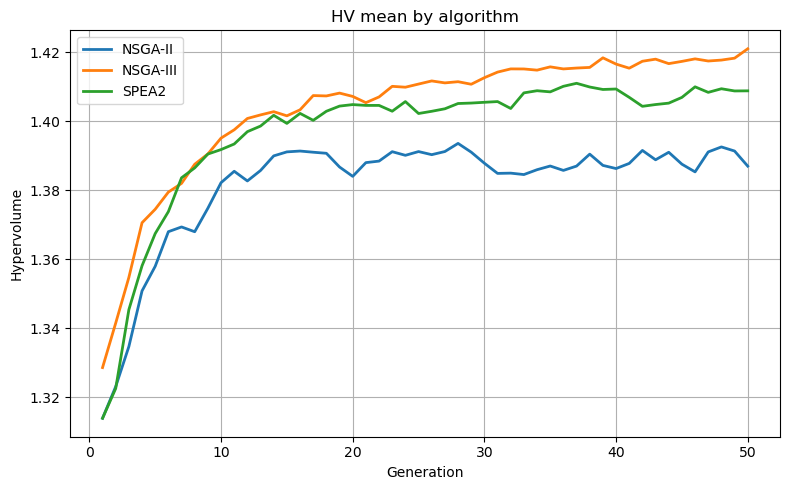

Saved: .\Datos\Transformados\Optimizacion\outputs\moea\figures\hv_medio_vs_generacion_algoritmos.png


In [13]:
# HV por generación: una curva por algoritmo (media de las 3 seeds)

plt.figure(figsize=(8,5))

for algo in algorithms_to_run:
    
    # apilar HV de todas las seeds de ese algoritmo
    hv_matrix = np.vstack([
        run["history_df"]["hv"].values
        for run in runs[algo]
    ])
    
    hv_mean = hv_matrix.mean(axis=0)
    generaciones = np.arange(1, len(hv_mean) + 1)

    plt.plot(
        generaciones,
        hv_mean,
        label=algo,
        linewidth=2
    )

plt.xlabel("Generation")
plt.ylabel("Hypervolume")
plt.title("HV mean by algorithm")
plt.legend()
plt.grid(True)
plt.tight_layout()

ruta_fig = os.path.join(FIG_DIR, "hv_medio_vs_generacion_algoritmos.png")
plt.savefig(ruta_fig, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", ruta_fig)

In [14]:
for algo in algorithms_to_run:
    print(f"\n{algo}")
    for run in runs[algo]:
        seed = run["metrics"]["seed"]
        hv_hist_last = run["history_df"]["hv"].iloc[-1]
        hv_final = run["metrics"]["hv"]
        print(f"seed {seed} -> hv_hist_last={hv_hist_last:.6f} | hv_final={hv_final:.6f}")


NSGA-II
seed 42 -> hv_hist_last=1.387900 | hv_final=1.387900
seed 342 -> hv_hist_last=1.378769 | hv_final=1.378769
seed 2024 -> hv_hist_last=1.394346 | hv_final=1.394346

NSGA-III
seed 42 -> hv_hist_last=1.429238 | hv_final=1.424729
seed 342 -> hv_hist_last=1.409940 | hv_final=1.394493
seed 2024 -> hv_hist_last=1.423919 | hv_final=1.412631

SPEA2
seed 42 -> hv_hist_last=1.403598 | hv_final=1.403598
seed 342 -> hv_hist_last=1.407514 | hv_final=1.407514
seed 2024 -> hv_hist_last=1.415408 | hv_final=1.415408


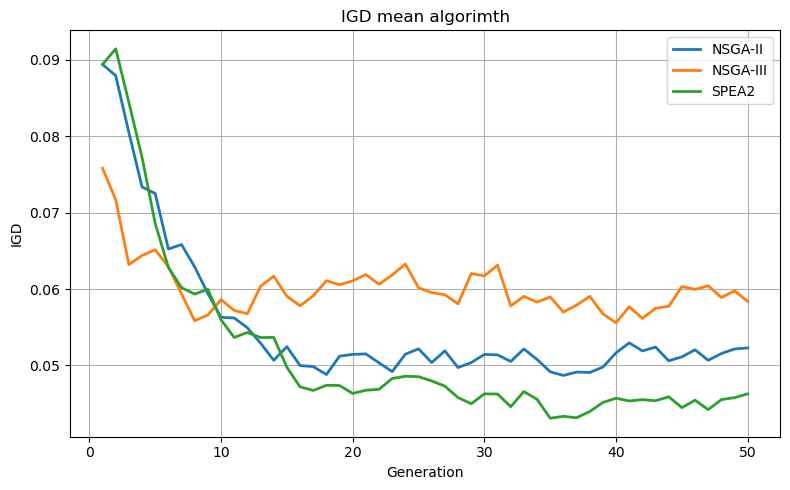

Saved: .\Datos\Transformados\Optimizacion\outputs\moea\figures\igd_medio_vs_generacion_algoritmos.png


In [15]:
# IGD por generación: una curva por algoritmo (media de las 3 seeds)

plt.figure(figsize=(8,5))

for algo in algorithms_to_run:

    # juntar IGD de las 3 seeds
    igd_matrix = np.vstack([
        run["history_df"]["igd"].values
        for run in runs[algo]
    ])

    # media por generación
    igd_mean = igd_matrix.mean(axis=0)

    generaciones = np.arange(1, len(igd_mean) + 1)

    plt.plot(
        generaciones,
        igd_mean,
        label=algo,
        linewidth=2
    )

plt.xlabel("Generation")
plt.ylabel("IGD")
plt.title("IGD mean algorimth")

plt.legend()
plt.grid(True)
plt.tight_layout()

ruta_fig = os.path.join(
    FIG_DIR,
    "igd_medio_vs_generacion_algoritmos.png"
)

plt.savefig(
    ruta_fig,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved:", ruta_fig)

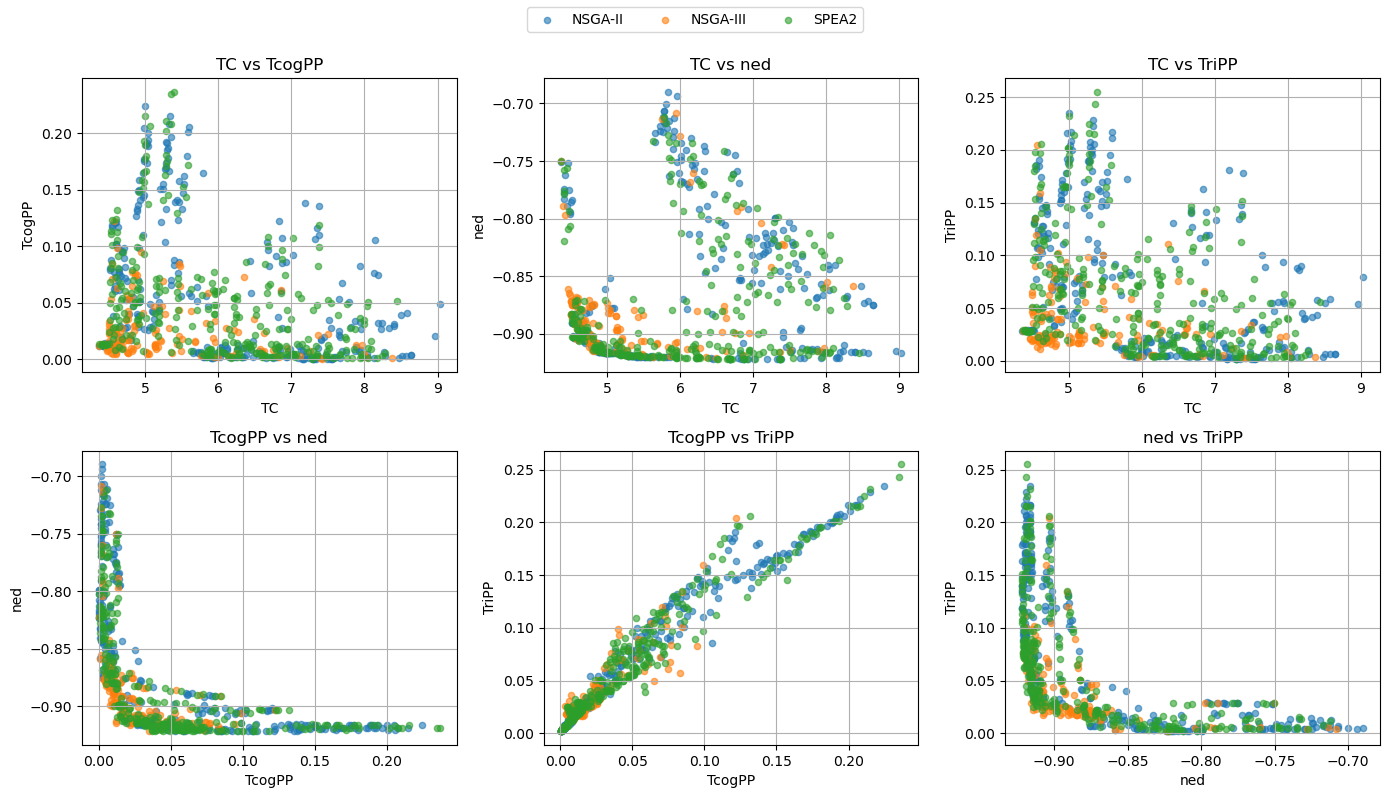

Saved: .\Datos\Transformados\Optimizacion\outputs\moea\figures\final_fronts_comparison_grid.png


In [16]:
# Proyecciones 2D del frente final (con muestreo)

pairs = [(0,1), (0,2), (0,3), (1,2), (1,3), (2,3)]

MAX_POINTS = 300  # máximo por algoritmo

fig, axes = plt.subplots(2, 3, figsize=(14,8))
axes = axes.flatten()

for ax, (i, j) in zip(axes, pairs):

    for algo in algorithms_to_run:

        # juntar soluciones de las 3 seeds
        F_nd_algo = np.vstack([
            run["F_nd"]
            for run in runs[algo]
        ])

        # eliminar duplicados exactos
        F_nd_algo = np.unique(F_nd_algo, axis=0)

        # muestrear si hay demasiados puntos
        if len(F_nd_algo) > MAX_POINTS:
            idx = np.random.choice(
                len(F_nd_algo),
                size=MAX_POINTS,
                replace=False
            )
            F_nd_algo = F_nd_algo[idx]

        ax.scatter(
            F_nd_algo[:, i],
            F_nd_algo[:, j],
            s=20,
            alpha=0.6,
            label=algo
        )

    ax.set_xlabel(Y_cols[i])
    ax.set_ylabel(Y_cols[j])
    ax.set_title(f"{Y_cols[i]} vs {Y_cols[j]}")
    ax.grid(True)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3)

plt.tight_layout(rect=[0,0,1,0.95])

ruta_fig = os.path.join(FIG_DIR, "final_fronts_comparison_grid.png")
plt.savefig(ruta_fig, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", ruta_fig)

In [17]:
# =========================================
# Selección de la mejor seed por algoritmo
# =========================================

rows = []
best_runs = {}  # guardaremos el mejor run de cada algoritmo

for alg in algorithms_to_run:

    run_list = runs[alg]

    # Elegir la seed con mayor HV
    best_run = max(
        run_list,
        key=lambda r: r["metrics"]["hv"]
    )

    best_runs[alg] = best_run

    rows.append({
        "algorithm": alg,
        "best_seed": best_run["metrics"]["seed"],
        "hv": best_run["metrics"]["hv"],
        "igd": best_run["metrics"]["igd"],
        "spread": best_run["metrics"]["spread"]
    })

metrics_df = pd.DataFrame(rows)

print("Mejor seed seleccionada por algoritmo:")
display(metrics_df)

Mejor seed seleccionada por algoritmo:


,algorithm,best_seed,hv,igd,spread
0,NSGA-II,2024,1.394346,0.056696,0.517956
1,NSGA-III,42,1.424729,0.080299,0.333889
2,SPEA2,2024,1.415408,0.045969,0.444149


### Seleccion frente final

In [18]:
# =========================================
# Mezcla de NSGA-III + SPEA2 (mejores seeds)
# y selección de 100 soluciones
# =========================================

BEST_CONFIG = {
    "NSGA-III": 42,
    "SPEA2": 42
}

# 1) Recuperar las mejores runs
selected_runs = {}

for algo, seed_sel in BEST_CONFIG.items():
    run_sel = None
    for run in runs[algo]:
        if run["metrics"]["seed"] == seed_sel:
            run_sel = run
            break

    if run_sel is None:
        raise ValueError(f"No se encontró la seed {seed_sel} para {algo}")

    selected_runs[algo] = run_sel

# 2) Unir soluciones no dominadas de ambas runs
X_mix = np.vstack([
    selected_runs["NSGA-III"]["X_nd"],
    selected_runs["SPEA2"]["X_nd"]
])

F_mix = np.vstack([
    selected_runs["NSGA-III"]["F_nd"],
    selected_runs["SPEA2"]["F_nd"]
])

meta_mix = pd.DataFrame({
    "algorithm": (
        ["NSGA-III"] * len(selected_runs["NSGA-III"]["F_nd"]) +
        ["SPEA2"] * len(selected_runs["SPEA2"]["F_nd"])
    ),
    "seed": (
        [BEST_CONFIG["NSGA-III"]] * len(selected_runs["NSGA-III"]["F_nd"]) +
        [BEST_CONFIG["SPEA2"]] * len(selected_runs["SPEA2"]["F_nd"])
    )
})

# 3) Recalcular frente no dominado conjunto
nd_idx = NonDominatedSorting().do(F_mix, only_non_dominated_front=True)

X_union_nd = X_mix[nd_idx]
F_union_nd = F_mix[nd_idx]
meta_union_nd = meta_mix.iloc[nd_idx].reset_index(drop=True)

# 4) DataFrame completo del frente conjunto
pareto_mix_df = pd.DataFrame(X_union_nd, columns=X_cols)
for j, target in enumerate(Y_cols):
    pareto_mix_df[target] = F_union_nd[:, j]

pareto_mix_df = pd.concat([meta_union_nd, pareto_mix_df], axis=1)
pareto_mix_df["pct_train_used"] = PCT_FINAL
pareto_mix_df["n_obs_used"] = len(X_train_opt)

print("Soluciones no dominadas en la unión:", len(pareto_mix_df))

# Guardar frente conjunto completo
pareto_mix_path = os.path.join(OUT_DIR, "pareto_front_mix_nsga3_spea2_full.csv")
pareto_mix_df.to_csv(pareto_mix_path, index=False)

print("Archivo completo guardado en:")
print(pareto_mix_path)

display(pareto_mix_df.head())

Soluciones no dominadas en la unión: 133
Archivo completo guardado en:
.\Datos\Transformados\Optimizacion\outputs\moea\pareto_front_mix_nsga3_spea2_full.csv


,algorithm,seed,hm,alpha_m,er,dsi,bst,bss,TC,TcogPP,ned,TriPP,pct_train_used,n_obs_used
0,NSGA-III,42,1.001407,0.701386,1.899574,0.021866,45.072136,4.167407,4.564925,0.122201,-0.903324,0.204210,0.6,816
1,NSGA-III,42,1.096317,0.701229,1.201047,1.000985,45.560446,4.698731,4.602548,0.008343,-0.869081,0.011418,0.6,816
2,NSGA-III,42,1.415908,0.787378,1.750896,0.947737,45.433036,3.575516,5.211098,0.016410,-0.905378,0.024787,0.6,816
3,NSGA-III,42,3.183580,0.996156,1.873571,2.202707,45.335848,3.934182,7.425006,0.000468,-0.822917,0.002224,0.6,816
4,NSGA-III,42,1.106652,0.895035,1.814936,0.097461,45.562003,4.499134,5.237342,0.069456,-0.918121,0.072807,0.6,816


In [19]:
# =========================================
# Reducir el frente conjunto a 100 soluciones
# =========================================

N_KEEP = 100

if len(pareto_mix_df) <= N_KEEP:
    pareto_top100_df = pareto_mix_df.copy()
else:
    # Normalizar objetivos
    F_vals = pareto_mix_df[Y_cols].values.astype(float)
    f_min = F_vals.min(axis=0)
    f_max = F_vals.max(axis=0)

    denom = np.where((f_max - f_min) == 0, 1.0, (f_max - f_min))
    F_norm = (F_vals - f_min) / denom

    # Score auxiliar para ordenar el frente
    score = F_norm.sum(axis=1)

    tmp = pareto_mix_df.copy()
    tmp["score_aux"] = score
    tmp = tmp.sort_values("score_aux").reset_index(drop=True)

    # Muestreo uniforme sobre el frente ordenado
    idx_keep = np.linspace(0, len(tmp) - 1, N_KEEP).round().astype(int)
    pareto_top100_df = tmp.iloc[idx_keep].drop(columns=["score_aux"]).reset_index(drop=True)

pareto_top100_path = os.path.join(OUT_DIR, "pareto_front_mix_nsga3_spea2_top100.csv")
pareto_top100_df.to_csv(pareto_top100_path, index=False)

print("Archivo top100 guardado en:")
print(pareto_top100_path)
print("Número de soluciones guardadas:", len(pareto_top100_df))

display(pareto_top100_df.head())

Archivo top100 guardado en:
.\Datos\Transformados\Optimizacion\outputs\moea\pareto_front_mix_nsga3_spea2_top100.csv
Número de soluciones guardadas: 100


,algorithm,seed,hm,alpha_m,er,dsi,bst,bss,TC,TcogPP,ned,TriPP,pct_train_used,n_obs_used
0,NSGA-III,42,1.033413,0.795563,1.745611,0.848496,45.666437,5.218476,4.772104,0.017142,-0.901264,0.021820,0.6,816
1,NSGA-III,42,1.006716,0.740377,1.605082,0.845467,45.229756,4.262720,4.589282,0.015155,-0.890734,0.024423,0.6,816
2,NSGA-III,42,1.096317,0.701229,1.201047,1.000985,45.560446,4.698731,4.602548,0.008343,-0.869081,0.011418,0.6,816
3,NSGA-III,42,1.229345,0.727495,1.711954,0.926574,45.143627,4.302649,4.801830,0.009994,-0.890961,0.021618,0.6,816
4,NSGA-III,42,1.070649,0.700232,1.791302,0.940682,45.191498,4.996809,4.562009,0.005034,-0.870108,0.019894,0.6,816


In [20]:
pareto_top100_df["algorithm"].value_counts()

algorithm
SPEA2       63
NSGA-III    37
Name: count, dtype: int64